In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
train = pd.read_csv('./data-mining-2026-final-project/data/train.csv')
test  = pd.read_csv('./data-mining-2026-final-project/data/test.csv')
sample_sub = pd.read_csv('./data-mining-2026-final-project/sample_submission.csv')

train = train.sort_values(['region_id', 'date']).reset_index(drop=True)
test  = test.sort_values(['region_id', 'date']).reset_index(drop=True)

train['row_idx'] = train.groupby('region_id').cumcount()
test['row_idx']  = test.groupby('region_id').cumcount()
# FIX: parse month correctly regardless of year digit length
train['month'] = train['date'].str.split('-').str[1].astype(int)
test['month']  = test['date'].str.split('-').str[1].astype(int)

train['dow']     = train['row_idx'] % 7
test['dow']      = test['row_idx'] % 7
train['week_idx'] = train['row_idx'] // 7
test['week_idx']  = test['row_idx'] // 7

METEO_COLS = ['wind','wind_min','wind_max','wind_range',
              'humidity','tmp','tmp_range','tmp_max','tmp_min',
              'surf_tmp','surf_pre','dp_tmp','wb_tmp','prec']

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nRegions in train:", train['region_id'].nunique())
print("Regions in test: ", test['region_id'].nunique())
print("\nRows per region in train:", train.groupby('region_id').size().describe())
print("Rows per region in test: ", test.groupby('region_id').size().describe())

Train shape: (12319040, 21)
Test shape:  (204568, 20)

Regions in train: 2248
Regions in test:  2248

Rows per region in train: count   2248.0000
mean    5480.0000
std        0.0000
min     5480.0000
25%     5480.0000
50%     5480.0000
75%     5480.0000
max     5480.0000
dtype: float64
Rows per region in test:  count   2248.0000
mean      91.0000
std        0.0000
min       91.0000
25%       91.0000
50%       91.0000
75%       91.0000
max       91.0000
dtype: float64


=== SCORE DISTRIBUTION ===
score
0.0000    1048333
1.0000     303432
2.0000     186279
3.0000     118496
4.0000      69422
5.0000      31974
Name: count, dtype: int64

Score stats:
count   1757936.0000
mean          0.8357
std           1.2615
min           0.0000
25%           0.0000
50%           0.0000
75%           1.0000
max           5.0000
Name: score, dtype: float64

=== SCORE BY VALUE ===
  Score 0.0: 1,048,333 (59.6%)
  Score 1.0: 303,432 (17.3%)
  Score 2.0: 186,279 (10.6%)
  Score 3.0: 118,496 (6.7%)
  Score 4.0: 69,422 (3.9%)
  Score 5.0: 31,974 (1.8%)


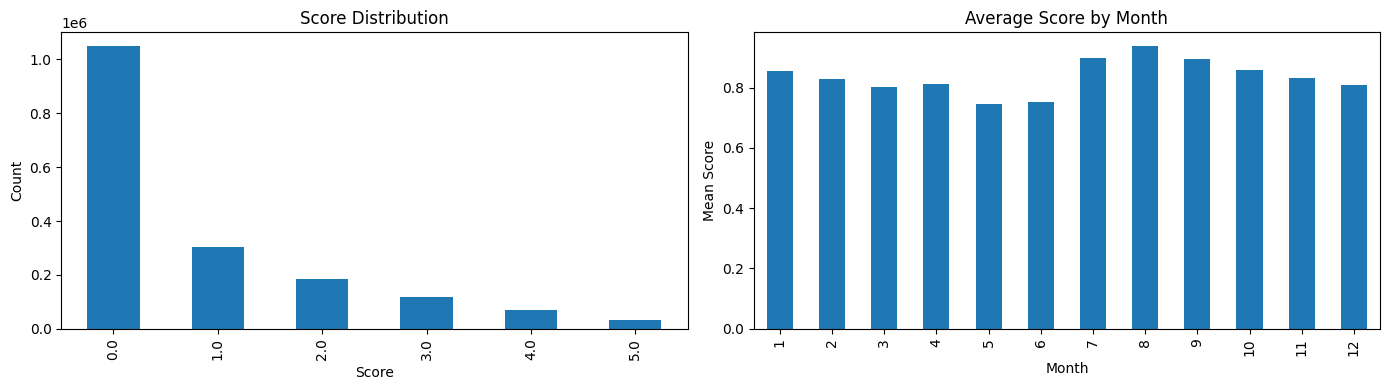

In [16]:
weekly_scores = train[train['dow'] == 6][['region_id', 'week_idx', 'month', 'score']].copy()
weekly_scores = weekly_scores[weekly_scores['score'].notna()]

print("=== SCORE DISTRIBUTION ===")
print(weekly_scores['score'].value_counts().sort_index())
print("\nScore stats:")
print(weekly_scores['score'].describe())

print("\n=== SCORE BY VALUE ===")
total = len(weekly_scores)
for s in sorted(weekly_scores['score'].unique()):
    count = (weekly_scores['score'] == s).sum()
    print(f"  Score {s}: {count:,} ({100*count/total:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
weekly_scores['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Score by month
monthly_score = weekly_scores.groupby('month')['score'].mean()
monthly_score.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Score by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Score')
plt.tight_layout()
plt.show()

In [17]:
print("=== SCORE PERSISTENCE ANALYSIS ===")

# How often does score stay the same week to week?
ws = weekly_scores.sort_values(['region_id', 'week_idx']).copy()
ws['prev_score'] = ws.groupby('region_id')['score'].shift(1)
ws['score_diff'] = ws['score'] - ws['prev_score']

print("Week-to-week score changes:")
print(ws['score_diff'].value_counts().sort_index())
print(f"\nScore unchanged: {(ws['score_diff']==0).mean():.1%}")
print(f"Score changed by 1: {(ws['score_diff'].abs()==1).mean():.1%}")
print(f"Score changed by 2+: {(ws['score_diff'].abs()>=2).mean():.1%}")

# Transition matrix
print("\n=== SCORE TRANSITION MATRIX ===")
ws_valid = ws[ws['prev_score'].notna()].copy()
ws_valid['prev_score'] = ws_valid['prev_score'].astype(int)
ws_valid['score'] = ws_valid['score'].astype(int)
transition = pd.crosstab(
    ws_valid['prev_score'],
    ws_valid['score'],
    normalize='index'
).round(3)
print("Rows=current score, Cols=next score (probability):")
print(transition)

# Autocorrelation at different lags
print("\n=== AUTOCORRELATION BY LAG (weeks) ===")
for lag in [1, 2, 4, 8, 13, 26]:
    ws[f'lag{lag}'] = ws.groupby('region_id')['score'].shift(lag)
    corr = ws['score'].corr(ws[f'lag{lag}'])
    print(f"  Lag {lag:2d} weeks: {corr:.4f}")

=== SCORE PERSISTENCE ANALYSIS ===
Week-to-week score changes:
score_diff
-5.0000          2
-4.0000         35
-3.0000        293
-2.0000       3598
-1.0000      71249
0.0000     1603032
1.0000       77015
2.0000         451
3.0000           5
4.0000           8
Name: count, dtype: int64

Score unchanged: 91.2%
Score changed by 1: 8.4%
Score changed by 2+: 0.2%

=== SCORE TRANSITION MATRIX ===
Rows=current score, Cols=next score (probability):
score           0      1      2      3      4      5
prev_score                                          
0          0.9630 0.0370 0.0000 0.0000 0.0000 0.0000
1          0.1220 0.8130 0.0650 0.0000 0.0000 0.0000
2          0.0110 0.0930 0.8390 0.0580 0.0000 0.0000
3          0.0010 0.0080 0.0800 0.8610 0.0490 0.0000
4          0.0000 0.0010 0.0070 0.0760 0.8810 0.0340
5          0.0000 0.0000 0.0010 0.0060 0.0670 0.9260

=== AUTOCORRELATION BY LAG (weeks) ===
  Lag  1 weeks: 0.9700
  Lag  2 weeks: 0.9400
  Lag  4 weeks: 0.8818
  Lag  8 weeks: 0.

=== REGIONAL SCORE DISTRIBUTION ===
Region-level score statistics:
           mean       std    median  pct_zero  pct_severe  autocorr_lag1
count 2248.0000 2248.0000 2248.0000 2248.0000   2248.0000      2248.0000
mean     0.8357    1.1090    0.3468    0.5963      0.1251         0.9487
std      0.4763    0.3696    0.5603    0.1610      0.1057         0.0361
min      0.0844    0.2782    0.0000    0.0908      0.0000         0.7801
25%      0.4485    0.8332    0.0000    0.4706      0.0396         0.9328
50%      0.7404    1.0970    0.0000    0.5959      0.0921         0.9600
75%      1.2059    1.4135    1.0000    0.7238      0.1995         0.9750
max      2.2558    2.0334    3.0000    0.9156      0.5192         0.9944

Regions with highest mean score:
     region_id   mean    std  pct_zero  pct_severe
447      R1714 2.2558 1.6992    0.2494      0.4642
460      R1726 2.2199 1.6891    0.2494      0.4514
1966       R68 2.1918 1.2858    0.1125      0.4309
684       R199 2.1803 1.8640    0.2992

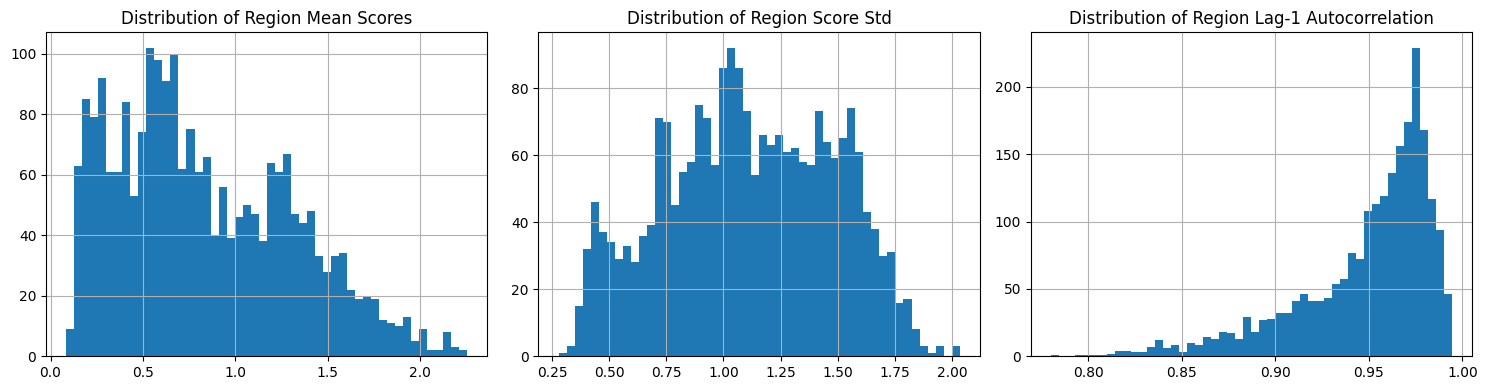

In [18]:
print("=== REGIONAL SCORE DISTRIBUTION ===")

region_stats = weekly_scores.groupby('region_id')['score'].agg([
    'mean', 'std', 'median',
    lambda x: (x == 0).mean(),
    lambda x: (x >= 3).mean(),
    lambda x: x.autocorr(lag=1)
]).reset_index()
region_stats.columns = ['region_id', 'mean', 'std', 'median',
                         'pct_zero', 'pct_severe', 'autocorr_lag1']

print("Region-level score statistics:")
print(region_stats.describe())

print("\nRegions with highest mean score:")
print(region_stats.nlargest(10, 'mean')[['region_id','mean','std','pct_zero','pct_severe']])

print("\nRegions with lowest mean score:")
print(region_stats.nsmallest(10, 'mean')[['region_id','mean','std','pct_zero','pct_severe']])

print("\nRegions with highest autocorrelation (most persistent drought):")
print(region_stats.nlargest(10, 'autocorr_lag1')[['region_id','mean','autocorr_lag1']])

print("\nRegions with lowest autocorrelation (most volatile):")
print(region_stats.nsmallest(10, 'autocorr_lag1')[['region_id','mean','autocorr_lag1']])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
region_stats['mean'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of Region Mean Scores')
region_stats['std'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribution of Region Score Std')
region_stats['autocorr_lag1'].hist(bins=50, ax=axes[2])
axes[2].set_title('Distribution of Region Lag-1 Autocorrelation')
plt.tight_layout()
plt.show()

In [19]:
print("=== METEO FEATURE STATISTICS ===")
print(train[METEO_COLS].describe())

print("\n=== METEO MISSING VALUES ===")
print(train[METEO_COLS].isnull().sum())

print("\n=== METEO CORRELATION WITH SCORE ===")
# Merge score onto daily data
score_days = train[train['dow'] == 6][['region_id', 'week_idx', 'score']].copy()
train_scored = train.merge(score_days, on=['region_id', 'week_idx'], suffixes=('', '_weekly'))

for col in METEO_COLS:
    corr = train_scored[col].corr(train_scored['score_weekly'])
    print(f"  {col:15s}: {corr:+.4f}")

print("\n=== METEO FEATURE CORRELATIONS WITH EACH OTHER ===")
corr_matrix = train[METEO_COLS].corr()
print(corr_matrix.round(2))

# Which meteo features are most correlated with each other?
print("\nHighly correlated pairs (>0.9):")
for i in range(len(METEO_COLS)):
    for j in range(i+1, len(METEO_COLS)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.9:
            print(f"  {METEO_COLS[i]} vs {METEO_COLS[j]}: {c:.4f}")

=== METEO FEATURE STATISTICS ===
               wind      wind_min      wind_max    wind_range      humidity  \
count 12319040.0000 12319040.0000 12319040.0000 12319040.0000 12319040.0000   
mean         3.6468        1.9487        5.3421        3.3935        7.8000   
std          1.8797        1.3713        2.6566        1.9872        4.7286   
min          0.2500        0.0000        0.5400        0.2000        0.1200   
25%          2.2000        0.9500        3.2400        1.9000        3.7700   
50%          3.2500        1.6800        4.8500        2.9400        6.7600   
75%          4.7100        2.6300        6.9300        4.4200       11.3200   
max         24.9400       17.2000       36.2800       28.2500       22.9200   

                tmp     tmp_range       tmp_max       tmp_min      surf_tmp  \
count 12319040.0000 12319040.0000 12319040.0000 12319040.0000 12319040.0000   
mean        12.9492       11.3449       18.8824        7.5375       13.0682   
std         10.964

In [20]:
print("=== TRAIN/TEST GAP ANALYSIS ===")

# Build weekly dataset quickly for gap analysis
train_weekly = train[train['dow'] == 6][['region_id', 'week_idx', 'month', 'score'] + METEO_COLS].copy()
test_weekly  = test[test['dow'] == 6][['region_id', 'week_idx', 'month'] + METEO_COLS].copy()

train_last_week = train_weekly.groupby('region_id')['week_idx'].max()
test_first_week = test_weekly.groupby('region_id')['week_idx'].min()
test_last_week  = test_weekly.groupby('region_id')['week_idx'].max()

gap = test_first_week - train_last_week
print("Gap between train end and test start (in weeks):")
print(gap.describe())
print("Gap value counts:")
print(gap.value_counts().head(10))

print("\nTest window length (weeks):")
print((test_last_week - test_first_week + 1).describe())

# Last known score per region
last_known_score = (train_weekly[train_weekly['score'].notna()]
                    .sort_values(['region_id', 'week_idx'])
                    .groupby('region_id')['score'].last())
print("\nLast known score distribution (end of training):")
print(last_known_score.value_counts().sort_index())
print("Mean last known score:", last_known_score.mean())

=== TRAIN/TEST GAP ANALYSIS ===
Gap between train end and test start (in weeks):
count   2248.0000
mean    -781.0000
std        0.0000
min     -781.0000
25%     -781.0000
50%     -781.0000
75%     -781.0000
max     -781.0000
Name: week_idx, dtype: float64
Gap value counts:
week_idx
-781    2248
Name: count, dtype: int64

Test window length (weeks):
count   2248.0000
mean      13.0000
std        0.0000
min       13.0000
25%       13.0000
50%       13.0000
75%       13.0000
max       13.0000
Name: week_idx, dtype: float64

Last known score distribution (end of training):
score
0.0000    1838
1.0000     185
2.0000     127
3.0000      66
4.0000      19
5.0000      13
Name: count, dtype: int64
Mean last known score: 0.34608540925266906


In [21]:
print("=== TRAIN VS TEST METEO DISTRIBUTION ===")

train_meteo_weekly = train[train['dow'] == 6][METEO_COLS].copy()
test_meteo_weekly  = test[test['dow'] == 6][METEO_COLS].copy()

print(f"{'Feature':<15} {'Train Mean':>12} {'Test Mean':>12} {'Train Std':>12} {'Test Std':>12} {'Shift':>8}")
print("-" * 65)
for col in METEO_COLS:
    tr_mean = train_meteo_weekly[col].mean()
    te_mean = test_meteo_weekly[col].mean()
    tr_std  = train_meteo_weekly[col].std()
    te_std  = test_meteo_weekly[col].std()
    shift   = (te_mean - tr_mean) / tr_std
    print(f"{col:<15} {tr_mean:>12.4f} {te_mean:>12.4f} {tr_std:>12.4f} {te_std:>12.4f} {shift:>8.4f}")

print("\nShift = (test_mean - train_mean) / train_std")
print("Values > 0.5 or < -0.5 indicate meaningful distribution shift")

# KS test for each feature
print("\n=== KOLMOGOROV-SMIRNOV TEST (train vs test distribution) ===")
print("p-value < 0.05 means distributions are significantly different")
for col in METEO_COLS:
    ks_stat, p_val = stats.ks_2samp(
        train_meteo_weekly[col].dropna(),
        test_meteo_weekly[col].dropna()
    )
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"  {col:<15}: KS={ks_stat:.4f}, p={p_val:.4f} {sig}")

=== TRAIN VS TEST METEO DISTRIBUTION ===
Feature           Train Mean    Test Mean    Train Std     Test Std    Shift
-----------------------------------------------------------------
wind                  3.6370       3.3219       1.8651       1.7033  -0.1690
wind_min              1.9314       1.7468       1.3570       1.2464  -0.1360
wind_max              5.3401       4.9171       2.6429       2.4429  -0.1601
wind_range            3.4087       3.1702       1.9887       1.8593  -0.1199
humidity              7.8724       9.5669       4.7626       4.4387   0.3558
tmp                  13.0564      18.4928      10.9901       8.6162   0.4947
tmp_range            11.3207      12.1871       4.0754       3.9307   0.2126
tmp_max              18.9755      24.9130      11.5875       9.1027   0.5124
tmp_min               7.6548      12.7258      10.6783       8.5062   0.4749
surf_tmp             13.1637      18.7215      11.2607       8.9084   0.4936
surf_pre             95.9269      95.9176     

In [22]:
print("=== SCORE VS METEO RELATIONSHIPS ===")

# Build weekly with score and month included
train_weekly_full = train.groupby(['region_id', 'week_idx']).agg(
    prec_mean=('prec', 'mean'),
    prec_sum=('prec', 'sum'),
    humidity_mean=('humidity', 'mean'),
    tmp_mean=('tmp', 'mean'),
    month=('month', 'first'),
).reset_index()

# Merge score from score days (dow==6)
score_days = train[train['dow'] == 6][['region_id', 'week_idx', 'score']].copy()
train_weekly_full = train_weekly_full.merge(score_days, on=['region_id', 'week_idx'], how='left')
train_weekly_full = train_weekly_full[train_weekly_full['score'].notna()]

print("Correlation of weekly aggregated meteo with score:")
for col in ['prec_mean', 'prec_sum', 'humidity_mean', 'tmp_mean']:
    corr = train_weekly_full[col].corr(train_weekly_full['score'])
    print(f"  {col:<20}: {corr:+.4f}")

train_weekly_full['prec_quartile'] = pd.qcut(
    train_weekly_full['prec_mean'], 4, labels=['Q1\n(driest)', 'Q2', 'Q3', 'Q4\n(wettest)']
)
print("\nMean score by precipitation quartile:")
print(train_weekly_full.groupby('prec_quartile')['score'].agg(['mean', 'std', 'count']))

print("\n=== ROLLING PRECIPITATION VS SCORE ===")
for window in [4, 8, 13, 26]:
    train_weekly_full[f'prec_roll{window}'] = (
        train_weekly_full.sort_values(['region_id', 'week_idx'])
        .groupby('region_id')['prec_mean']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    corr = train_weekly_full[f'prec_roll{window}'].corr(train_weekly_full['score'])
    print(f"  Rolling {window:2d}w prec vs score: {corr:+.4f}")

=== SCORE VS METEO RELATIONSHIPS ===
Correlation of weekly aggregated meteo with score:
  prec_mean           : -0.1592
  prec_sum            : -0.1592
  humidity_mean       : -0.0568
  tmp_mean            : +0.1009

Mean score by precipitation quartile:
                mean    std   count
prec_quartile                      
Q1\n(driest)  1.1697 1.4197  439912
Q2            0.9017 1.2817  439362
Q3            0.7342 1.1822  439222
Q4\n(wettest) 0.5366 1.0456  439440

=== ROLLING PRECIPITATION VS SCORE ===
  Rolling  4w prec vs score: -0.3162
  Rolling  8w prec vs score: -0.3772
  Rolling 13w prec vs score: -0.4050
  Rolling 26w prec vs score: -0.4144


=== SEASONALITY ANALYSIS ===
Score by month:
        mean    std   count
month                      
1     0.8525 1.2586  146120
2     0.8277 1.2411  137128
3     0.8022 1.1991  150616
4     0.7968 1.2134  143872
5     0.7470 1.2103  148368
6     0.7761 1.2395  146120
7     0.8933 1.3055  146120
8     0.9617 1.3580  152864
9     0.8769 1.2902  143872
10    0.8483 1.2872  148368
11    0.8403 1.2723  146120
12    0.8018 1.2353  148368

Precipitation by month:
        mean    std
month              
1     1.9166 2.6549
2     2.1136 2.7922
3     2.2645 2.8318
4     2.7508 2.9466
5     3.0388 3.0148
6     3.2280 3.1967
7     2.8854 2.7043
8     2.9454 3.4495
9     2.6205 3.4519
10    2.4409 3.3408
11    2.1245 2.9908
12    2.3560 3.1274

Temperature by month:
         mean    std
month               
1      0.3741 7.5338
2      2.3707 7.5969
3      8.0170 6.8474
4     12.6574 5.9969
5     18.3239 5.3798
6     22.9619 4.6557
7     25.0290 3.7568
8     23.9356 3.9964
9     19.7764 4.9130
10  

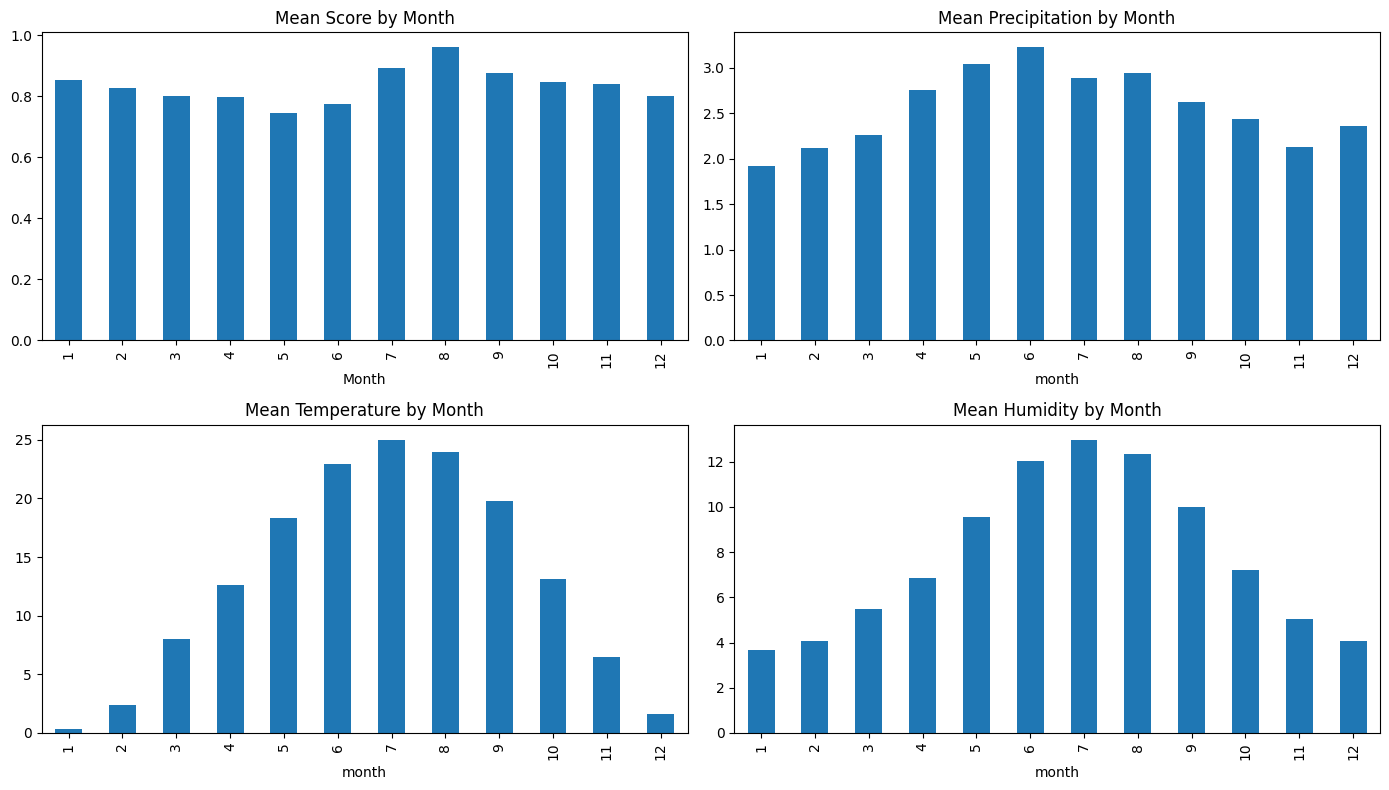


=== TEST WINDOW MONTHS ===
Test months distribution:
month
1      640
2      718
3     1126
4     1230
5     1376
6     2338
7     3239
8     4738
9     6138
10    4713
11    2160
12     808
Name: count, dtype: int64

Train months distribution:
month
1     150616
2     134880
3     150616
4     141624
5     152864
6     143872
7     148368
8     150616
9     143872
10    148368
11    146120
12    146120
Name: count, dtype: int64


In [23]:
print("=== SEASONALITY ANALYSIS ===")

print("Score by month:")
monthly = train_weekly_full.groupby('month')['score'].agg(['mean', 'std', 'count'])
print(monthly)

print("\nPrecipitation by month:")
print(train_weekly_full.groupby('month')['prec_mean'].agg(['mean', 'std']))

print("\nTemperature by month:")
print(train_weekly_full.groupby('month')['tmp_mean'].agg(['mean', 'std']))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

monthly['mean'].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Mean Score by Month')
axes[0,0].set_xlabel('Month')

train_weekly_full.groupby('month')['prec_mean'].mean().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Mean Precipitation by Month')

train_weekly_full.groupby('month')['tmp_mean'].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Mean Temperature by Month')

train_weekly_full.groupby('month')['humidity_mean'].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Mean Humidity by Month')

plt.tight_layout()
plt.show()

# Test months vs train months
print("\n=== TEST WINDOW MONTHS ===")
test_months = test[test['dow'] == 6]['month'].value_counts().sort_index()
train_months = train[train['dow'] == 6]['month'].value_counts().sort_index()
print("Test months distribution:")
print(test_months)
print("\nTrain months distribution:")
print(train_months)

In [24]:
print("=== SCORE TREND OVER TRAINING PERIOD ===")

# Is drought getting worse/better over training period?
ws_time = weekly_scores.copy()
ws_time['week_bucket'] = pd.qcut(ws_time['week_idx'], 10, labels=False)

print("Mean score by decile of training period (0=earliest, 9=latest):")
print(ws_time.groupby('week_bucket')['score'].agg(['mean', 'std']))

# Last 52 weeks vs first 52 weeks
early = weekly_scores[weekly_scores['week_idx'] < 52]['score']
late  = weekly_scores[weekly_scores['week_idx'] >= weekly_scores['week_idx'].max() - 52]['score']
print(f"\nFirst 52 weeks mean score: {early.mean():.4f}")
print(f"Last  52 weeks mean score: {late.mean():.4f}")
print(f"Trend: {'increasing' if late.mean() > early.mean() else 'decreasing'} drought over training period")

ks_stat, p_val = stats.ks_2samp(early.dropna(), late.dropna())
print(f"KS test early vs late: stat={ks_stat:.4f}, p={p_val:.4f}")

=== SCORE TREND OVER TRAINING PERIOD ===
Mean score by decile of training period (0=earliest, 9=latest):
              mean    std
week_bucket              
0           0.6171 1.1146
1           0.9208 1.1878
2           0.9936 1.3448
3           0.6177 1.0470
4           0.6134 1.0778
5           1.5653 1.6513
6           1.1198 1.4455
7           0.7243 1.1902
8           0.5439 0.9746
9           0.6342 1.0327

First 52 weeks mean score: 0.6773
Last  52 weeks mean score: 0.7124
Trend: increasing drought over training period
KS test early vs late: stat=0.0592, p=0.0000


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

print("=== QUICK FEATURE IMPORTANCE (Random Forest on weekly data) ===")

# Build simple feature set
rf_data = train_weekly_full.dropna(subset=['score']).copy()

# Add lag features
rf_data = rf_data.sort_values(['region_id', 'week_idx'])
rf_data['score_lag1'] = rf_data.groupby('region_id')['score'].shift(1)
rf_data['score_lag4'] = rf_data.groupby('region_id')['score'].shift(4)
rf_data['prec_roll4'] = rf_data.groupby('region_id')['prec_mean'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean())
rf_data['prec_roll13'] = rf_data.groupby('region_id')['prec_mean'].transform(
    lambda x: x.shift(1).rolling(13, min_periods=1).mean())

SIMPLE_FEATURES = ['prec_mean', 'prec_sum', 'humidity_mean', 'tmp_mean',
                   'prec_roll4', 'prec_roll13', 'score_lag1', 'score_lag4', 'month']

rf_clean = rf_data[SIMPLE_FEATURES + ['score']].dropna()
print(f"Training RF on {len(rf_clean):,} rows...")

rf = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(rf_clean[SIMPLE_FEATURES], rf_clean['score'])

imp = pd.DataFrame({
    'feature': SIMPLE_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importances:")
print(imp.to_string())

=== QUICK FEATURE IMPORTANCE (Random Forest on weekly data) ===
Training RF on 1,748,944 rows...

Feature importances:
         feature  importance
6     score_lag1      0.9865
1       prec_sum      0.0057
0      prec_mean      0.0051
3       tmp_mean      0.0012
4     prec_roll4      0.0009
2  humidity_mean      0.0003
5    prec_roll13      0.0002
8          month      0.0001
7     score_lag4      0.0000


In [26]:
print("=== HOW PREDICTABLE IS SCORE FROM METEO ALONE? ===")

# Train model WITHOUT score lags, evaluate on holdout
METEO_ONLY = ['prec_mean', 'prec_sum', 'humidity_mean', 'tmp_mean',
              'prec_roll4', 'prec_roll13', 'month']

rf_meteo = rf_data[METEO_ONLY + ['score', 'week_idx']].dropna()

# Time split
split = rf_meteo['week_idx'].quantile(0.8)
tr = rf_meteo[rf_meteo['week_idx'] <= split]
va = rf_meteo[rf_meteo['week_idx'] >  split]

rf2 = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf2.fit(tr[METEO_ONLY], tr['score'])
preds = rf2.predict(va[METEO_ONLY])
mae_meteo_only = np.mean(np.abs(va['score'].values - preds))

# With score lags
WITH_LAGS = METEO_ONLY + ['score_lag1', 'score_lag4']
rf_lags = rf_data[WITH_LAGS + ['score', 'week_idx']].dropna()
tr2 = rf_lags[rf_lags['week_idx'] <= split]
va2 = rf_lags[rf_lags['week_idx'] >  split]

rf3 = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf3.fit(tr2[WITH_LAGS], tr2['score'])
preds2 = rf3.predict(va2[WITH_LAGS])
mae_with_lags = np.mean(np.abs(va2['score'].values - preds2))

print(f"Val MAE (meteo only):    {mae_meteo_only:.4f}")
print(f"Val MAE (with score lags): {mae_with_lags:.4f}")
print(f"Score lag improvement: {mae_meteo_only - mae_with_lags:.4f}")
print(f"\nThis tells us how much score lags help beyond meteo features.")
print(f"If improvement is large, score lags are critical.")
print(f"If improvement is small, meteo features are sufficient.")

# Baseline: predict regional mean
region_mean_map = rf_data.groupby('region_id')['score'].mean()
# Predict last known score
print(f"\nBaseline (predict 0 always): {va['score'].mean():.4f} (just score mean as MAE)")
print(f"Baseline (predict mean always): {np.mean(np.abs(va['score'] - va['score'].mean())):.4f}")

=== HOW PREDICTABLE IS SCORE FROM METEO ALONE? ===
Val MAE (meteo only):    0.6775
Val MAE (with score lags): 0.1230
Score lag improvement: 0.5545

This tells us how much score lags help beyond meteo features.
If improvement is large, score lags are critical.
If improvement is small, meteo features are sufficient.

Baseline (predict 0 always): 0.5890 (just score mean as MAE)
Baseline (predict mean always): 0.7790


In [27]:
!pip install lightgbm

python(14559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [28]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import gc
import warnings
warnings.filterwarnings('ignore')

In [29]:
train = pd.read_csv('./data-mining-2026-final-project/data/train.csv')
test  = pd.read_csv('./data-mining-2026-final-project/data/test.csv')
sample_sub = pd.read_csv('./data-mining-2026-final-project/sample_submission.csv')

train = train.sort_values(['region_id', 'date']).reset_index(drop=True)
test  = test.sort_values(['region_id', 'date']).reset_index(drop=True)

train['row_idx'] = train.groupby('region_id').cumcount()
test['row_idx']  = test.groupby('region_id').cumcount()

# FIX: parse month correctly regardless of year digit length
train['month'] = train['date'].str.split('-').str[1].astype(int)
test['month']  = test['date'].str.split('-').str[1].astype(int)

train['dow']     = train['row_idx'] % 7
test['dow']      = test['row_idx'] % 7
train['week_idx'] = train['row_idx'] // 7
test['week_idx']  = test['row_idx'] // 7

# Verify fix
print("Month value counts after fix:")
print(train['month'].value_counts().sort_index())
print("\nAny month <= 0?", (train['month'] <= 0).sum())

Month value counts after fix:
month
1     1045320
2      953152
3     1045320
4     1011600
5     1045320
6     1011600
7     1045320
8     1045320
9     1011600
10    1045320
11    1011600
12    1047568
Name: count, dtype: int64

Any month <= 0? 0


In [30]:
def build_weekly(df, meteo_cols, has_score=True):
    df = df.copy()
    df['week_idx'] = df['row_idx'] // 7
    grouped = df.groupby(['region_id', 'week_idx'])
    
    meteo_agg = grouped[meteo_cols].agg(['mean', 'min', 'max', 'std'])
    meteo_agg.columns = ['_'.join(c) for c in meteo_agg.columns]
    meteo_agg = meteo_agg.reset_index()
    
    score_day = df[df['dow'] == 6][['region_id', 'week_idx', 'month']].copy()
    meteo_agg = meteo_agg.merge(score_day, on=['region_id', 'week_idx'], how='left')
    
    if has_score:
        scores = df[df['dow'] == 6][['region_id', 'week_idx', 'score']].copy()
        meteo_agg = meteo_agg.merge(scores, on=['region_id', 'week_idx'], how='left')
    
    return meteo_agg.sort_values(['region_id', 'week_idx']).reset_index(drop=True)

print("Building weekly datasets...")
weekly_train = build_weekly(train, METEO_COLS, has_score=True)
weekly_test  = build_weekly(test,  METEO_COLS, has_score=False)

del train, test
gc.collect()

METEO_AGG_COLS = [c for c in weekly_train.columns
                  if c not in ['region_id', 'week_idx', 'score', 'month']]

print("Weekly train:", weekly_train.shape)
print("Weekly test: ", weekly_test.shape)
print("Score nulls in weekly train:", weekly_train['score'].isna().sum())

Building weekly datasets...
Weekly train: (1760184, 60)
Weekly test:  (29224, 59)
Score nulls in weekly train: 2248


In [31]:
region_stats = (
    weekly_train[weekly_train['score'].notna()]
    .groupby('region_id')['score']
    .agg(region_score_mean='mean',
         region_score_std='std',
         region_score_median='median')
    .reset_index()
)

# Last 13 non-NaN scores per region
last_scores_by_region = {}
for rid, grp in weekly_train[weekly_train['score'].notna()].groupby('region_id'):
    scores = grp.sort_values('week_idx')['score'].tolist()
    last_scores_by_region[rid] = scores[-13:]

print("Region stats shape:", region_stats.shape)
print("R1  last 13:", last_scores_by_region.get('R1'))
print("R68 last 13:", last_scores_by_region.get('R68'))
print("Any NaN in score hists:", 
      any(np.isnan(v) for h in last_scores_by_region.values() for v in h))

Region stats shape: (2248, 4)
R1  last 13: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
R68 last 13: [4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
Any NaN in score hists: False


In [32]:
import numpy as np
import pandas as pd
import gc

# 1. Add the memory reduction helper function
def reduce_mem_usage(df):
    """Iterates through all columns and modifies numeric types to reduce memory usage."""
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    # Using float32 is generally safer for LightGBM than float16
                    df[col] = df[col].astype(np.float32) 
                else:
                    df[col] = df[col].astype(np.float32)
                    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    return df

SCORE_LAGS    = [1, 2, 3, 4, 5, 6, 8, 13]
SCORE_WINDOWS = [2, 4, 8, 13, 26]

def add_features(df, meteo_agg_cols):
    # Avoid .copy() if possible, but sorting inplace helps
    df.sort_values(['region_id', 'week_idx'], inplace=True)
    g = df.groupby('region_id')

    for lag in SCORE_LAGS:
        df[f'score_lag{lag}'] = g['score'].shift(lag)
    for w in SCORE_WINDOWS:
        df[f'score_roll_mean_{w}'] = g['score'].transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        df[f'score_roll_std_{w}'] = g['score'].transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).std())
    df['score_trend_4w']  = g['score'].shift(1) - g['score'].shift(4)
    df['score_trend_8w']  = g['score'].shift(1) - g['score'].shift(8)
    df['score_trend_13w'] = g['score'].shift(1) - g['score'].shift(13)

    for col in meteo_agg_cols:
        df[f'{col}_lag1'] = g[col].shift(1)
        df[f'{col}_lag2'] = g[col].shift(2)
        df[f'{col}_lag4'] = g[col].shift(4)

    for col in ['prec_mean', 'humidity_mean', 'tmp_mean']:
        df[f'{col}_roll4']  = g[col].transform(lambda x: x.shift(1).rolling(4,  min_periods=1).mean())
        df[f'{col}_roll13'] = g[col].transform(lambda x: x.shift(1).rolling(13, min_periods=1).mean())

    df['month_clean'] = df['month'].clip(1, 12)
    
    monthly_prec = (df[df['score'].notna()]
                    .groupby(['region_id', 'month_clean'])['prec_mean']
                    .agg(prec_mo_mean='mean', prec_mo_std='std')
                    .reset_index())
    monthly_prec['prec_mo_std'] = monthly_prec['prec_mo_std'].fillna(1.0).clip(lower=0.1)
    
    monthly_tmp = (df[df['score'].notna()]
                   .groupby(['region_id', 'month_clean'])['tmp_mean']
                   .agg(tmp_mo_mean='mean', tmp_mo_std='std')
                   .reset_index())
    monthly_tmp['tmp_mo_std'] = monthly_tmp['tmp_mo_std'].fillna(1.0).clip(lower=0.1)

    df = df.merge(monthly_prec, on=['region_id', 'month_clean'], how='left')
    df = df.merge(monthly_tmp,  on=['region_id', 'month_clean'], how='left')
    
    df['prec_anomaly'] = ((df['prec_mean'] - df['prec_mo_mean']) / df['prec_mo_std']).clip(-5, 5)
    df['tmp_anomaly']  = ((df['tmp_mean']  - df['tmp_mo_mean'])  / df['tmp_mo_std']).clip(-5, 5)
    
    # Re-create groupby object after merges (Fixes the KeyError)
    g_merged = df.groupby('region_id')
    
    df['prec_anomaly_roll4']  = g_merged['prec_anomaly'].transform(lambda x: x.rolling(4,  min_periods=1).mean())
    df['prec_anomaly_roll13'] = g_merged['prec_anomaly'].transform(lambda x: x.rolling(13, min_periods=1).mean())
    df['tmp_anomaly_roll4']   = g_merged['tmp_anomaly'].transform(lambda x: x.rolling(4,  min_periods=1).mean())
    df['tmp_anomaly_roll13']  = g_merged['tmp_anomaly'].transform(lambda x: x.rolling(13, min_periods=1).mean())

    df = df.merge(region_stats, on='region_id', how='left')
    df['month_sin'] = np.sin(2 * np.pi * df['month_clean'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_clean'] / 12)
    
    return df, monthly_prec, monthly_tmp

print("Compressing initial dataframe...")
weekly_train = reduce_mem_usage(weekly_train)

print("Adding features to weekly_train...")
weekly_train, monthly_prec_baseline, monthly_tmp_baseline = add_features(weekly_train, METEO_AGG_COLS)

print("Compressing dataframe with newly generated features...")
weekly_train = reduce_mem_usage(weekly_train)
gc.collect()

SCORE_LAG_COLS = (
    [f'score_lag{l}' for l in SCORE_LAGS] +
    [f'score_roll_mean_{w}' for w in SCORE_WINDOWS] +
    [f'score_roll_std_{w}'  for w in SCORE_WINDOWS] +
    ['score_trend_4w', 'score_trend_8w', 'score_trend_13w']
)
METEO_LAG_COLS = (
    [f'{c}_lag1' for c in METEO_AGG_COLS] +
    [f'{c}_lag2' for c in METEO_AGG_COLS] +
    [f'{c}_lag4' for c in METEO_AGG_COLS]
)
METEO_ROLL_COLS = [
    'prec_mean_roll4', 'prec_mean_roll13',
    'humidity_mean_roll4', 'humidity_mean_roll13',
    'tmp_mean_roll4', 'tmp_mean_roll13'
]
SPI_COLS  = ['prec_anomaly', 'tmp_anomaly',
             'prec_anomaly_roll4', 'prec_anomaly_roll13',
             'tmp_anomaly_roll4',  'tmp_anomaly_roll13']
REGION_COLS = ['region_score_mean', 'region_score_std', 'region_score_median']
TIME_COLS   = ['month_sin', 'month_cos']

FEATURE_COLS = SCORE_LAG_COLS + METEO_LAG_COLS + list(METEO_AGG_COLS) + METEO_ROLL_COLS + SPI_COLS + REGION_COLS + TIME_COLS

print("Total features:", len(FEATURE_COLS))
print("Weekly train shape:", weekly_train.shape)

# Memory Fix: Overwrite dataframe in place instead of using .copy()
cols_keep = ['region_id', 'week_idx', 'score'] + FEATURE_COLS
weekly_train = weekly_train[cols_keep] 
gc.collect() # Force garbage collection

Compressing initial dataframe...
Memory usage of dataframe is 805.75 MB
Memory usage after optimization is: 406.23 MB
Decreased by 49.6%
Adding features to weekly_train...
Compressing dataframe with newly generated features...
Memory usage of dataframe is 2004.30 MB
Memory usage after optimization is: 1823.01 MB
Decreased by 9.0%
Total features: 262
Weekly train shape: (1760184, 271)


0

In [33]:
from collections import defaultdict
from tqdm import tqdm

N_SEEDS = 1

cols_keep = ['region_id', 'week_idx', 'score'] + FEATURE_COLS
train_slim = weekly_train[cols_keep].copy()
del weekly_train
gc.collect()

train_slim['week_rank'] = train_slim.groupby('region_id')['week_idx'].rank(ascending=True)
max_rank   = train_slim.groupby('region_id')['week_rank'].max().min()
val_cutoff = max_rank - 52

tr_base  = train_slim[train_slim['week_rank'] <= val_cutoff]
val_base = train_slim[train_slim['week_rank'] >  val_cutoff]

models = defaultdict(list)

for h in tqdm(range(1, 6), desc='Horizons'):
    y_tr  = tr_base.groupby('region_id')['score'].shift(-h).loc[tr_base.index]
    y_val = val_base.groupby('region_id')['score'].shift(-h).loc[val_base.index]

    tr_mask  = y_tr.notna()  & tr_base['score_lag13'].notna()
    val_mask = y_val.notna() & val_base['score_lag13'].notna()

    X_tr  = tr_base.loc[tr_mask,  FEATURE_COLS].copy()
    y_tr  = y_tr[tr_mask]
    X_val = val_base.loc[val_mask, FEATURE_COLS]
    y_val = y_val[val_mask]

    print(f"\n--- Horizon {h} | Train: {len(X_tr):,} | Val: {len(X_val):,} ---")

    for seed in tqdm(range(N_SEEDS), desc=f'  H{h} seeds', leave=False):
        np.random.seed(seed * 10 + h)
        gap_mask = np.random.random(len(X_tr)) < 0.25
        X_tr_s = X_tr.copy()
        X_tr_s.loc[X_tr_s.index[gap_mask], SCORE_LAG_COLS] = np.nan

        m = lgb.LGBMRegressor(
            objective='regression_l1',
            metric='mae',
            n_estimators=3000,
            learning_rate=0.05,
            num_leaves=127,
            min_child_samples=50,
            feature_fraction=0.7,
            bagging_fraction=0.8,
            bagging_freq=1,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )
        m.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False),
                       lgb.log_evaluation(9999)]
        )
        val_preds = np.clip(m.predict(X_val), 0, 5)
        val_mae = mean_absolute_error(y_val, val_preds)
        models[h].append(m)
        tqdm.write(f"  H{h} seed {seed}  best_iter={m.best_iteration_}  val_mae={val_mae:.4f}")

    del X_tr, y_tr, X_val, y_val
    gc.collect()

del tr_base, val_base, train_slim
gc.collect()
print("\nAll models trained!")

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]


--- Horizon 1 | Train: 1,611,816 | Val: 112,400 ---


                                               
Horizons:  20%|██        | 1/5 [03:38<14:33, 218.50s/it]

  H1 seed 0  best_iter=188  val_mae=0.1437

--- Horizon 2 | Train: 1,609,568 | Val: 110,152 ---


                                                        
Horizons:  40%|████      | 2/5 [07:13<10:49, 216.63s/it]

...

  H4 seed 0  best_iter=125  val_mae=0.2916

--- Horizon 5 | Train: 1,602,824 | Val: 103,408 ---


                                                        
Horizons: 100%|██████████| 5/5 [17:02<00:00, 195.02s/it]

  H5 seed 0  best_iter=76  val_mae=0.3287


Horizons: 100%|██████████| 5/5 [17:02<00:00, 204.43s/it]


All models trained!


In [34]:
# Add SPI features to test using the same monthly baselines from training
weekly_test['month_clean'] = weekly_test['month'].clip(1, 12)
weekly_test = weekly_test.merge(monthly_prec_baseline, on=['region_id', 'month_clean'], how='left')
weekly_test = weekly_test.merge(monthly_tmp_baseline,  on=['region_id', 'month_clean'], how='left')

weekly_test['prec_anomaly'] = ((weekly_test['prec_mean'] - weekly_test['prec_mo_mean']) / weekly_test['prec_mo_std']).clip(-5, 5)
weekly_test['tmp_anomaly']  = ((weekly_test['tmp_mean']  - weekly_test['tmp_mo_mean'])  / weekly_test['tmp_mo_std']).clip(-5, 5)

g_test = weekly_test.groupby('region_id')
weekly_test['prec_anomaly_roll4']  = g_test['prec_anomaly'].transform(lambda x: x.rolling(4,  min_periods=1).mean())
weekly_test['prec_anomaly_roll13'] = g_test['prec_anomaly'].transform(lambda x: x.rolling(13, min_periods=1).mean())
weekly_test['tmp_anomaly_roll4']   = g_test['tmp_anomaly'].transform(lambda x: x.rolling(4,  min_periods=1).mean())
weekly_test['tmp_anomaly_roll13']  = g_test['tmp_anomaly'].transform(lambda x: x.rolling(13, min_periods=1).mean())

# Meteo rolling for test
for col in ['prec_mean', 'humidity_mean', 'tmp_mean']:
    weekly_test[f'{col}_roll4']  = g_test[col].transform(lambda x: x.rolling(4,  min_periods=1).mean())
    weekly_test[f'{col}_roll13'] = g_test[col].transform(lambda x: x.rolling(13, min_periods=1).mean())

weekly_test = weekly_test.merge(region_stats, on='region_id', how='left')
weekly_test['month_sin'] = np.sin(2 * np.pi * weekly_test['month_clean'] / 12)
weekly_test['month_cos'] = np.cos(2 * np.pi * weekly_test['month_clean'] / 12)

print("Test SPI features added.")
print("prec_anomaly_roll13 mean:", weekly_test['prec_anomaly_roll13'].mean())
print("NaN in test SPI cols:", weekly_test[SPI_COLS].isna().sum().sum())

Test SPI features added.
prec_anomaly_roll13 mean: -0.3107383906990862
NaN in test SPI cols: 0


In [35]:
def build_row(score_hist, grp, week_i, rstats):
    meteo_row  = grp.iloc[week_i]
    lag1_row   = grp.iloc[max(0, week_i - 1)]
    lag2_row   = grp.iloc[max(0, week_i - 2)]
    lag4_row   = grp.iloc[max(0, week_i - 4)]
    region_mean = float(rstats['region_score_mean'])

    row = {}
    for lag in SCORE_LAGS:
        row[f'score_lag{lag}'] = score_hist[-lag] if lag <= len(score_hist) else region_mean
    for w in SCORE_WINDOWS:
        recent = score_hist[-w:] if w <= len(score_hist) else score_hist
        row[f'score_roll_mean_{w}'] = np.mean(recent)
        row[f'score_roll_std_{w}']  = np.std(recent) if len(recent) > 1 else 0.0
    row['score_trend_4w']  = score_hist[-1] - score_hist[-4]  if len(score_hist) >= 4  else 0
    row['score_trend_8w']  = score_hist[-1] - score_hist[-8]  if len(score_hist) >= 8  else 0
    row['score_trend_13w'] = score_hist[-1] - score_hist[-13] if len(score_hist) >= 13 else 0

    for col in METEO_AGG_COLS:
        row[col]           = meteo_row[col]
        row[f'{col}_lag1'] = lag1_row[col]
        row[f'{col}_lag2'] = lag2_row[col]
        row[f'{col}_lag4'] = lag4_row[col]

    for col in ['prec_mean', 'humidity_mean', 'tmp_mean']:
        row[f'{col}_roll4']  = meteo_row[f'{col}_roll4']
        row[f'{col}_roll13'] = meteo_row[f'{col}_roll13']

    for col in SPI_COLS:
        row[col] = meteo_row[col]

    row['region_score_mean']   = rstats['region_score_mean']
    row['region_score_std']    = rstats['region_score_std']
    row['region_score_median'] = rstats['region_score_median']
    row['month_sin'] = float(meteo_row['month_sin'])
    row['month_cos'] = float(meteo_row['month_cos'])
    return row


weekly_test_feat = weekly_test.copy()
all_predictions = []

for region_id, grp in weekly_test_feat.groupby('region_id'):
    grp = grp.sort_values('week_idx').reset_index(drop=True)
    rstats = region_stats[region_stats['region_id'] == region_id].iloc[0]
    region_mean = float(rstats['region_score_mean'])

    score_hist = [region_mean] * 13
    for _ in range(2):
        score_hist = score_hist[-13:]
        for week_i in range(13):
            row = build_row(score_hist, grp, week_i, rstats)
            X = pd.DataFrame([row])[FEATURE_COLS]
            inferred = float(np.mean([np.clip(m.predict(X)[0], 0, 5) for m in models[1]]))
            score_hist.append(inferred)

    score_hist = score_hist[-13:]

    row = build_row(score_hist, grp, 12, rstats)
    X_pred = pd.DataFrame([row])[FEATURE_COLS]

    region_preds = []
    for h in range(1, 6):
        pred = float(np.mean([np.clip(m.predict(X_pred)[0], 0, 5) for m in models[h]]))
        region_preds.append(pred)

    all_predictions.append([region_id] + region_preds)

print(f"Done: {len(all_predictions)} regions")
print("R68:", [p for p in all_predictions if p[0]=='R68'])
print("R1: ", [p for p in all_predictions if p[0]=='R1'])

preds_df = pd.DataFrame(all_predictions,
    columns=['region_id','pred_week1','pred_week2','pred_week3','pred_week4','pred_week5'])
print("\nPrediction stats:")
print(preds_df[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']].describe())

Done: 2248 regions
R68: [['R68', 2.096615357180047, 2.0671131642137746, 1.9364792870165206, 2.0059470986064003, 1.9908007104756698]]
R1:  [['R1', 0.8243063227552644, 0.8096364915524926, 0.2705861122203357, 0.24632385298070222, 0.23328364390711095]]

Prediction stats:
       pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
count   2248.0000   2248.0000   2248.0000   2248.0000   2248.0000
mean       1.0303      0.9891      0.9887      0.9553      0.9034
std        0.5338      0.5683      0.6078      0.6377      0.6582
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.8800      0.7166      0.5665      0.4593      0.3523
50%        1.0406      1.0244      1.0090      0.9709      0.8530
75%        1.0915      1.1232      1.2491      1.2555      1.2730
max        3.3280      3.4513      3.8070      3.8629      3.3346


In [36]:
submission = pd.DataFrame(
    all_predictions,
    columns=['region_id','pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']
)
submission = sample_sub[['region_id']].merge(submission, on='region_id', how='left')

print("Submission shape:", submission.shape)
print(submission[submission['region_id'].isin(['R1','R68','R1714','R1726'])])
print("\nPrediction stats:")
print(submission[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']].describe())

submission.to_csv('submission.csv', index=False)
print("\nSaved submission.csv")

Submission shape: (2248, 6)
     region_id  pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
0           R1      0.8243      0.8096      0.2706      0.2463      0.2333
49         R68      2.0966      2.0671      1.9365      2.0059      1.9908
1221     R1714      2.0574      2.0193      2.0140      2.1229      2.0713
1233     R1726      2.0912      2.0307      2.0262      2.1181      1.9050

Prediction stats:
       pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
count   2248.0000   2248.0000   2248.0000   2248.0000   2248.0000
mean       1.0303      0.9891      0.9887      0.9553      0.9034
std        0.5338      0.5683      0.6078      0.6377      0.6582
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.8800      0.7166      0.5665      0.4593      0.3523
50%        1.0406      1.0244      1.0090      0.9709      0.8530
75%        1.0915      1.1232      1.2491      1.2555      1.2730
max        3.3280      3.4513      3.8070      3.8

In [37]:
import pandas as pd
import numpy as np

sub = pd.read_csv('submission.csv')
print("Before rounding:")
print(sub[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']].describe())

for col in ['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']:
    sub[col] = sub[col].round().clip(0, 5).astype(int)

print("\nAfter rounding:")
print(sub[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']].describe())

sub.to_csv('submission_rounded.csv', index=False)
print("\nSaved submission_rounded.csv")

Before rounding:
       pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
count   2248.0000   2248.0000   2248.0000   2248.0000   2248.0000
mean       1.0303      0.9891      0.9887      0.9553      0.9034
std        0.5338      0.5683      0.6078      0.6377      0.6582
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.8800      0.7166      0.5665      0.4593      0.3523
50%        1.0406      1.0244      1.0090      0.9709      0.8530
75%        1.0915      1.1232      1.2491      1.2555      1.2730
max        3.3280      3.4513      3.8070      3.8629      3.3346

After rounding:
       pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
count   2248.0000   2248.0000   2248.0000   2248.0000   2248.0000
mean       1.0085      0.9617      0.9395      0.9070      0.8794
std        0.5265      0.5826      0.6474      0.6782      0.7155
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        1.0000      1.0000      1.0000 

In [38]:
# What does the training score distribution look like?
print(sub[['pred_week1','pred_week2','pred_week3','pred_week4','pred_week5']].apply(pd.Series.value_counts).fillna(0).astype(int))

   pred_week1  pred_week2  pred_week3  pred_week4  pred_week5
0         273         395         512         597         704
1        1712        1575        1389        1295        1134
2         234         247         320         326         387
3          29          31          25          28          23
4           0           0           2           2           0
